In [44]:
# Cell 1
# =============================================================================
# Load & Concatenate Baseline Normalized Datasets Across All Nodes (Nodes A–H)
# =============================================================================

import os
import pandas as pd

# Define node identifiers and root dataset directory
NODES = ["A", "B", "C", "D", "E", "F", "G", "H"]
BASE_DIR = "dataset/normalized"

# Construct file paths for all normalized train and test splits
train_files = [os.path.join(BASE_DIR, f"Node_{node}_train_normalized.csv") for node in NODES]
test_files  = [os.path.join(BASE_DIR, f"Node_{node}_test_normalized.csv")  for node in NODES]

print("Loading normalized training datasets...")
for path in train_files:
    print(f"  - {path}")

print("\nLoading normalized testing datasets...")
for path in test_files:
    print(f"  - {path}")

# Load and concatenate data across all nodes
df_train_list = [pd.read_csv(p) for p in train_files]
df_test_list  = [pd.read_csv(p) for p in test_files]

df_train = pd.concat(df_train_list, ignore_index=True)
df_test  = pd.concat(df_test_list,  ignore_index=True)

# Display dataset shapes and target distribution
print("\n=== Combined Baseline Multi-Node Datasets (Nodes A–H) ===")
print(f"Combined Training Shape: {df_train.shape}")
print(f"Combined Testing Shape:  {df_test.shape}")
print(f"Columns: {df_train.columns.tolist()}")

print("\nTarget Label Distribution (Train):")
print(df_train["Attack"].value_counts())

print("\nTarget Label Distribution (Test):")
print(df_test["Attack"].value_counts())

Loading normalized training datasets...
  - dataset/normalized/Node_A_train_normalized.csv
  - dataset/normalized/Node_B_train_normalized.csv
  - dataset/normalized/Node_C_train_normalized.csv
  - dataset/normalized/Node_D_train_normalized.csv
  - dataset/normalized/Node_E_train_normalized.csv
  - dataset/normalized/Node_F_train_normalized.csv
  - dataset/normalized/Node_G_train_normalized.csv
  - dataset/normalized/Node_H_train_normalized.csv

Loading normalized testing datasets...
  - dataset/normalized/Node_A_test_normalized.csv
  - dataset/normalized/Node_B_test_normalized.csv
  - dataset/normalized/Node_C_test_normalized.csv
  - dataset/normalized/Node_D_test_normalized.csv
  - dataset/normalized/Node_E_test_normalized.csv
  - dataset/normalized/Node_F_test_normalized.csv
  - dataset/normalized/Node_G_test_normalized.csv
  - dataset/normalized/Node_H_test_normalized.csv

=== Combined Baseline Multi-Node Datasets (Nodes A–H) ===
Combined Training Shape: (406608, 7)
Combined Testing

In [45]:
# Cell 2
# =============================================================================
# Feature Preprocessing & Baseline Random Forest Classifier Training
# =============================================================================

import os
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, log_loss, mean_squared_error, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# -----------------------------------------------------------------------------
# 1. Feature Definition & One-Hot Encoding
# -----------------------------------------------------------------------------
TARGET_COL = "Attack"
FEATURE_COLS = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW", "State"]
NUMERIC_FEATURES = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
EXPECTED_FEATURE_ORDER = [
    "shunt_voltage", "bus_voltage_V", "current_mA", "power_mW",
    "State_idle", "State_charging"
]

# Separate features and target
X_train_raw = df_train[FEATURE_COLS].copy()
y_train_raw = df_train[TARGET_COL].copy()

X_test_raw  = df_test[FEATURE_COLS].copy()
y_test_raw  = df_test[TARGET_COL].copy()

# One-hot encode the categorical 'State' column
X_train = pd.get_dummies(X_train_raw, columns=["State"], drop_first=False)
X_test  = pd.get_dummies(X_test_raw,  columns=["State"], drop_first=False)

# Ensure both state dummy columns exist in both splits
for col in ["State_idle", "State_charging"]:
    if col not in X_train.columns:
        X_train[col] = 0
    if col not in X_test.columns:
        X_test[col] = 0

# Enforce consistent feature column order
X_train = X_train[EXPECTED_FEATURE_ORDER]
X_test  = X_test[EXPECTED_FEATURE_ORDER]

# Encode target categorical labels into integers
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)

# -----------------------------------------------------------------------------
# 2. Standardize Numerical Features
# -----------------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test_scaled[NUMERIC_FEATURES]  = scaler.transform(X_test[NUMERIC_FEATURES])

X_train_np = X_train_scaled.to_numpy()
X_test_np  = X_test_scaled.to_numpy()

print(f"Target classes mapped: {dict(zip(le.classes_, range(len(le.classes_))))}")
print(f"Final input features ({len(EXPECTED_FEATURE_ORDER)}): {EXPECTED_FEATURE_ORDER}")
print(f"Training samples: {X_train_np.shape[0]} | Test samples: {X_test_np.shape[0]}")

# -----------------------------------------------------------------------------
# 3. Train Baseline Random Forest Classifier & Evaluate OOB Metrics
# -----------------------------------------------------------------------------
rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

rf_final.fit(X_train_np, y_train)

# OOB class probabilities and derived hard predictions
oob_probs = rf_final.oob_decision_function_
oob_preds = np.argmax(oob_probs, axis=1)

# Calculate OOB Metrics
oob_macro_f1 = f1_score(y_train, oob_preds, average="macro")
oob_mse      = mean_squared_error(y_train, oob_preds)
oob_loss     = log_loss(y_train, oob_probs)
try:
    oob_roc_auc = roc_auc_score(y_train, oob_probs, multi_class="ovr", average="macro")
except ValueError:
    oob_roc_auc = np.nan

print("\nModel training complete.")
print("=== Out-Of-Bag (OOB) Performance ===")
print(f"  OOB Accuracy:          {rf_final.oob_score_:.6f}")
print(f"  Macro F1-Score:        {oob_macro_f1:.6f}")
print(f"  Mean Squared Error:    {oob_mse:.6f}")
print(f"  Log Loss:              {oob_loss:.6f}")
print(f"  ROC-AUC Score:         {oob_roc_auc:.6f}")

# -----------------------------------------------------------------------------
# 4. Global Combined Test Set Evaluation (df_test)
# -----------------------------------------------------------------------------
y_test_pred = rf_final.predict(X_test_np)
y_test_prob = rf_final.predict_proba(X_test_np)

test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")
test_mse      = mean_squared_error(y_test, y_test_pred)
test_loss     = log_loss(y_test, y_test_prob)
try:
    test_roc_auc = roc_auc_score(y_test, y_test_prob, multi_class="ovr", average="macro")
except ValueError:
    test_roc_auc = np.nan

print("\n=== Combined Test Set Performance (df_test) ===")
print(f"  Macro F1-Score:        {test_macro_f1:.6f}")
print(f"  Mean Squared Error:    {test_mse:.6f}")
print(f"  Log Loss:              {test_loss:.6f}")
print(f"  ROC-AUC Score:         {test_roc_auc:.6f}")

Target classes mapped: {'Backdoor': 0, 'none': 1, 'syn-flood': 2}
Final input features (6): ['shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW', 'State_idle', 'State_charging']
Training samples: 406608 | Test samples: 174408

Model training complete.
=== Out-Of-Bag (OOB) Performance ===
  OOB Accuracy:          0.896205
  Macro F1-Score:        0.876253
  Mean Squared Error:    0.116722
  Log Loss:              0.274251
  ROC-AUC Score:         0.970877

=== Combined Test Set Performance (df_test) ===
  Macro F1-Score:        0.878141
  Mean Squared Error:    0.114226
  Log Loss:              0.237548
  ROC-AUC Score:         0.973026


In [46]:
# Cell 3
# =============================================================================
# Serialize Baseline Model and Preprocessors to Disk (.joblib)
# =============================================================================

import os
import joblib

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Export model, label encoder, and fitted standard scaler for downstream tasks
joblib.dump(rf_final, os.path.join(MODEL_DIR, "rf_final.joblib"))
joblib.dump(le,      os.path.join(MODEL_DIR, "label_encoder.joblib"))
joblib.dump(scaler,  os.path.join(MODEL_DIR, "scaler.joblib"))

print(f"Successfully saved baseline model and preprocessors to '{MODEL_DIR}':")
print("  - rf_final.joblib")
print("  - label_encoder.joblib")
print("  - scaler.joblib")

Successfully saved baseline model and preprocessors to 'models':
  - rf_final.joblib
  - label_encoder.joblib
  - scaler.joblib


Evaluating Baseline RF Performance across individual node test splits:

=== Node A (Samples: 21801) ===
  Macro F1-Score:        0.842192
  Mean Squared Error:    0.167699
  Log Loss:              0.340539
  ROC-AUC Score:         0.945751
  Confusion Matrix (Rows: True, Cols: Predicted):
  Classes: ['Backdoor' 'none' 'syn-flood']
  [[4184, 1895, 5], [1523, 8110, 0], [52, 10, 6022]]

=== Node B (Samples: 21801) ===
  Macro F1-Score:        0.853995
  Mean Squared Error:    0.151094
  Log Loss:              0.326832
  ROC-AUC Score:         0.951240
  Confusion Matrix (Rows: True, Cols: Predicted):
  Classes: ['Backdoor' 'none' 'syn-flood']
  [[4059, 1514, 4], [1686, 8961, 0], [19, 2, 5556]]

=== Node C (Samples: 21801) ===
  Macro F1-Score:        0.846028
  Mean Squared Error:    0.151140
  Log Loss:              0.328952
  ROC-AUC Score:         0.947068
  Confusion Matrix (Rows: True, Cols: Predicted):
  Classes: ['Backdoor' 'none' 'syn-flood']
  [[3407, 1659, 4], [1555, 10106, 0], 

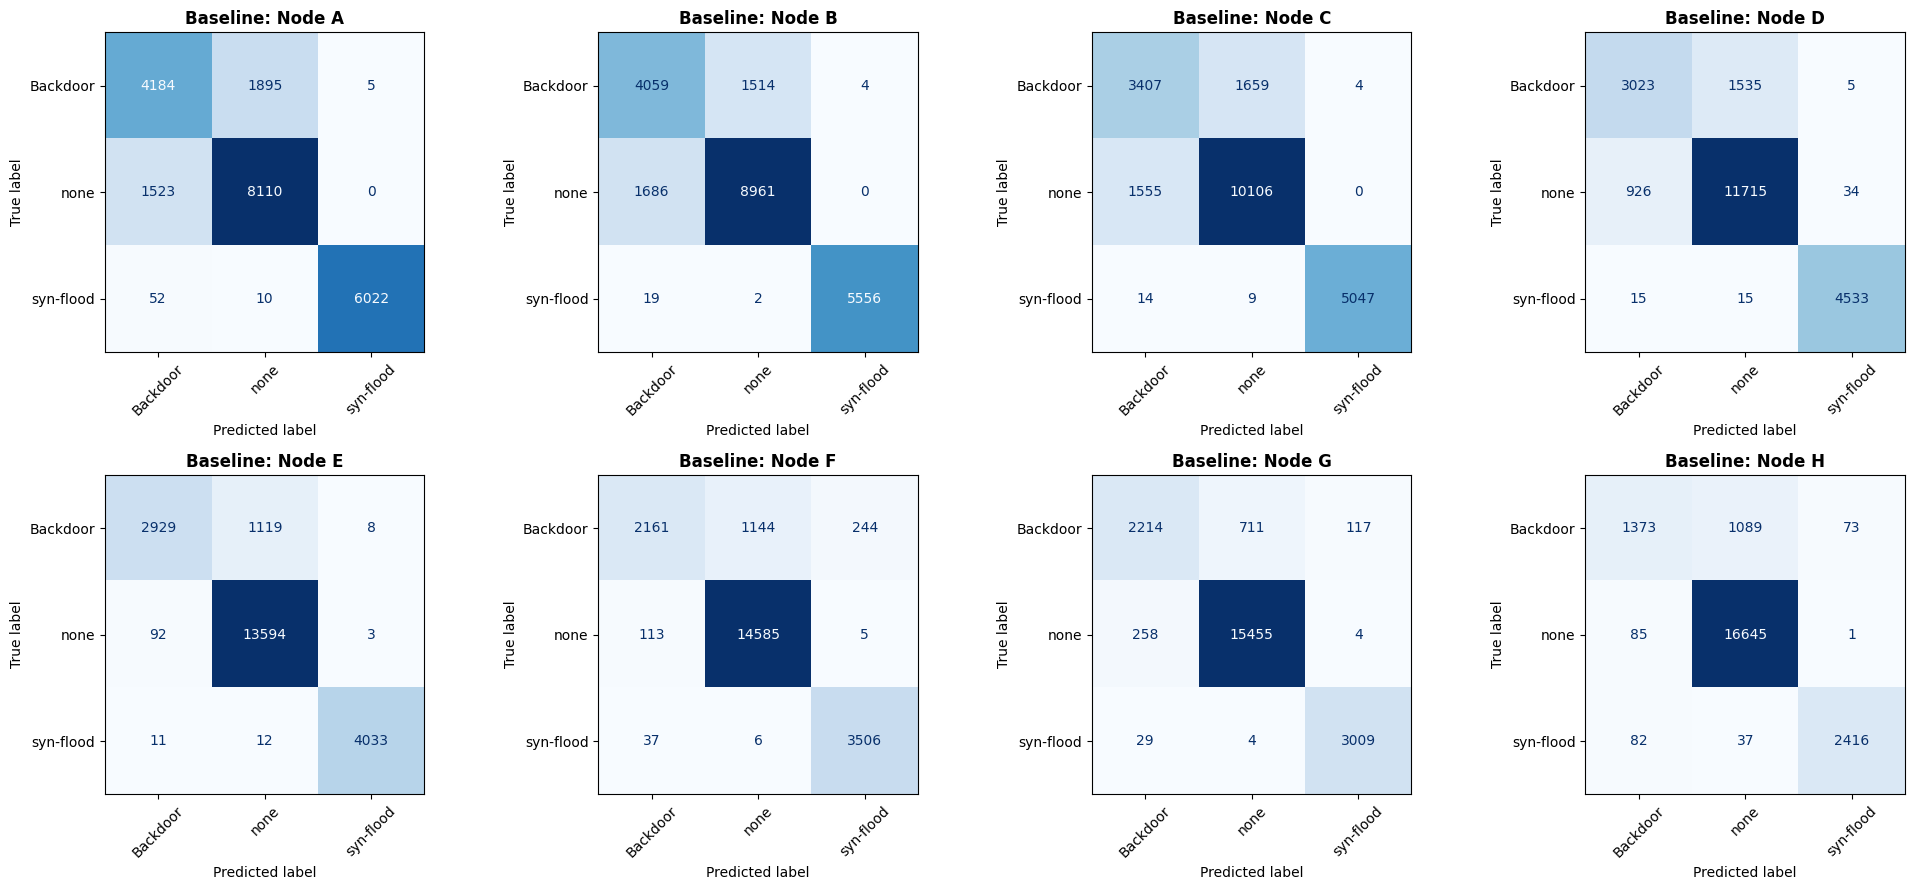

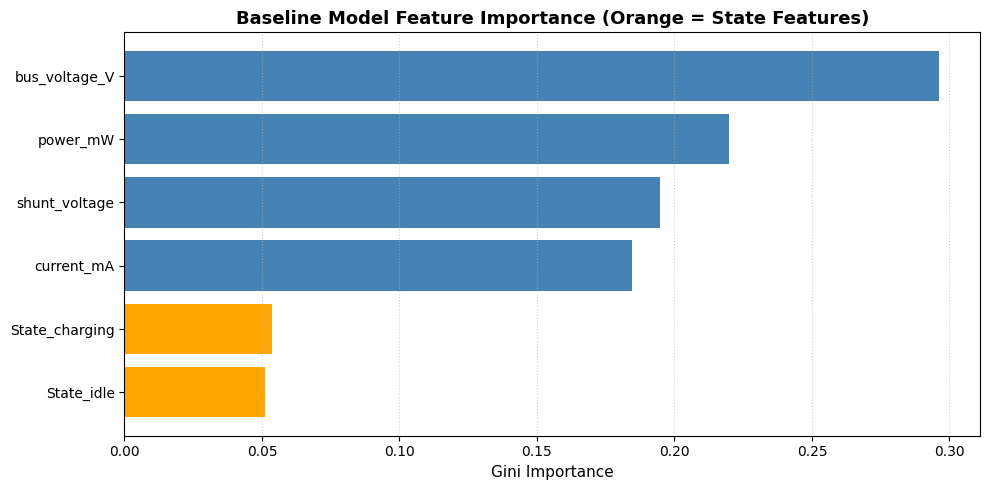

In [48]:
# Cell 4
# =============================================================================
# Per-Node Evaluation (Nodes A–H), Confusion Matrices & Feature Importance Plot
# =============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_squared_error,
    roc_auc_score,
)

def prepare_node_features(df_raw, scaler_instance, expected_cols, numeric_cols):
    """
    Applies one-hot encoding, column alignment, and numeric standardization to a single node's data.
    """
    X_raw = df_raw[FEATURE_COLS].copy()
    X = pd.get_dummies(X_raw, columns=["State"], drop_first=False)

    for col in ["State_idle", "State_charging"]:
        if col not in X.columns:
            X[col] = 0

    X = X[expected_cols]
    X_scaled = X.copy()
    X_scaled[numeric_cols] = scaler_instance.transform(X[numeric_cols])
    return X_scaled.to_numpy()

print("Evaluating Baseline RF Performance across individual node test splits:\n")

metrics_records = []
cm_dict = {}

for node in NODES:
    test_path = os.path.join(BASE_DIR, f"Node_{node}_test_normalized.csv")
    df_test_node = pd.read_csv(test_path)

    # Prepare features and encode target labels
    X_test_node_np = prepare_node_features(
        df_test_node, scaler, EXPECTED_FEATURE_ORDER, NUMERIC_FEATURES
    )
    y_test_node = le.transform(df_test_node[TARGET_COL])

    # Predict classes and probabilities
    y_test_node_pred = rf_final.predict(X_test_node_np)
    y_test_node_prob = rf_final.predict_proba(X_test_node_np)

    # Calculate performance metrics
    macro_f1 = f1_score(y_test_node, y_test_node_pred, average="macro")
    mse_error = mean_squared_error(y_test_node, y_test_node_pred)
    loss = log_loss(y_test_node, y_test_node_prob, labels=np.arange(len(le.classes_)))

    try:
        roc_auc = roc_auc_score(
            y_test_node,
            y_test_node_prob,
            multi_class="ovr",
            average="macro",
            labels=np.arange(len(le.classes_)),
        )
    except ValueError:
        roc_auc = np.nan

    cm = confusion_matrix(
        y_test_node, y_test_node_pred, labels=np.arange(len(le.classes_))
    )
    cm_dict[node] = cm

    metrics_records.append({
        "Node": f"Node {node}",
        "Samples": len(df_test_node),
        "Macro F1": macro_f1,
        "MSE": mse_error,
        "Log Loss": loss,
        "ROC-AUC": roc_auc,
    })

    print(f"=== Node {node} (Samples: {len(df_test_node)}) ===")
    print(f"  Macro F1-Score:        {macro_f1:.6f}")
    print(f"  Mean Squared Error:    {mse_error:.6f}")
    print(f"  Log Loss:              {loss:.6f}")
    print(f"  ROC-AUC Score:         {roc_auc:.6f}")
    print("  Confusion Matrix (Rows: True, Cols: Predicted):")
    print(f"  Classes: {le.classes_}")
    print(f"  {cm.tolist()}\n")

# Summary DataFrame & Overall Averages
df_metrics = pd.DataFrame(metrics_records)
print("=============================================================================")
print("SUMMARY ACROSS ALL NODES (BASELINE MODEL):")
print(df_metrics.to_string(index=False))

print("\n=== Macro Average Across All Nodes ===")
print(f"  Avg Macro F1-Score:    {df_metrics['Macro F1'].mean():.6f}")
print(f"  Avg Mean Squared Error:{df_metrics['MSE'].mean():.6f}")
print(f"  Avg Log Loss:          {df_metrics['Log Loss'].mean():.6f}")
print(f"  Avg ROC-AUC Score:     {df_metrics['ROC-AUC'].mean():.6f}\n")

# -----------------------------------------------------------------------------
# 1. Plot Confusion Matrices for All Nodes
# -----------------------------------------------------------------------------
n_nodes = len(NODES)
cols = 4
rows = (n_nodes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
axes = np.array(axes).reshape(-1)

for idx, node in enumerate(NODES):
    ax = axes[idx]
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_dict[node],
        display_labels=le.classes_
    )
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )
    ax.set_title(f"Baseline: Node {node}", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)

# Hide any unused subplots
for idx in range(n_nodes, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 2. Plot Baseline Feature Importance Distribution
# -----------------------------------------------------------------------------
df_base_imp = pd.DataFrame({
    "Feature": EXPECTED_FEATURE_ORDER,
    "Importance": rf_final.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(
    df_base_imp["Feature"],
    df_base_imp["Importance"],
    color=["orange" if "State" in f else "steelblue" for f in df_base_imp["Feature"]]
)
plt.title("Baseline Model Feature Importance (Orange = State Features)", fontsize=13, fontweight="bold")
plt.xlabel("Gini Importance", fontsize=11)
plt.grid(True, axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [33]:
#SUMMARY#
txt = '''
Summary of Changes in Notebook 03:
- Cell Consolidation & Re-ordering: Placed artifact saving (Cell 3) immediately after training (Cell 2) to ensure files are saved before running evaluation.
- Removed Redundant Cells: Deleted empty placeholder and exploratory comment cells.
- Unified Preprocessing Helper: Streamlined prepare_node_features to eliminate code duplication.
- Standardized Configuration: Used uppercase constants (NODES, FEATURE_COLS, MODEL_DIR, etc.).  
'''
print(txt)


Summary of Changes in Notebook 03:
- Cell Consolidation & Re-ordering: Placed artifact saving (Cell 3) immediately after training (Cell 2) to ensure files are saved before running evaluation.
- Removed Redundant Cells: Deleted empty placeholder and exploratory comment cells.
- Unified Preprocessing Helper: Streamlined prepare_node_features to eliminate code duplication.
- Standardized Configuration: Used uppercase constants (NODES, FEATURE_COLS, MODEL_DIR, etc.).  

